In [1]:
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import tensorflow as tf  # Import TensorFlow for building neural network models
import seaborn as sns  # Import Seaborn for statistical plotting
import matplotlib.pyplot as plt  # Import Matplotlib for creating plots
from sklearn.model_selection import train_test_split  # Import train_test_split for splitting datasets
from sklearn.metrics import mean_squared_error, r2_score  # Import metrics for evaluating models
from sklearn.linear_model import LinearRegression, HuberRegressor, ElasticNet  # Import linear regression models
from sklearn.decomposition import PCA  # Import PCA for dimensionality reduction
from sklearn.cross_decomposition import PLSRegression  # Import PLSRegression for partial least squares regression
from sklearn.preprocessing import SplineTransformer  # Import SplineTransformer for spline feature transformation
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor  # Import ensemble regression models

plt.style.use('seaborn-v0_8-whitegrid')  # Set the plotting style to Seaborn whitegrid
plt.rcParams['figure.figsize'] = (12, 8)  # Set default figure size for plots to 12x8 inches


In [2]:
n_stocks = 10  # Define the number of stocks
n_months = 24  # Define the number of months (time periods)
n_characteristics = 5  # Define the number of stock-specific characteristics
n_macro_factors = 3  # Define the number of macroeconomic factors

np.random.seed(42)  # Set the random seed for reproducibility
stock_characteristics = np.random.rand(n_stocks, n_months, n_characteristics)  # Generate random stock characteristic data
macro_factors = np.random.rand(n_months, n_macro_factors)  # Generate random macroeconomic factor data

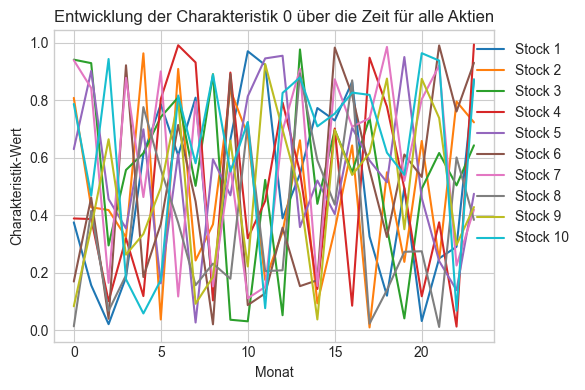

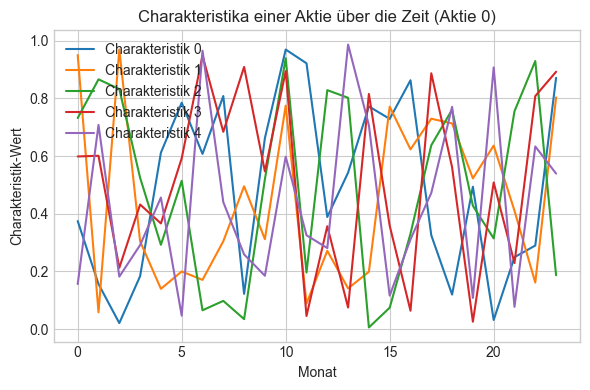

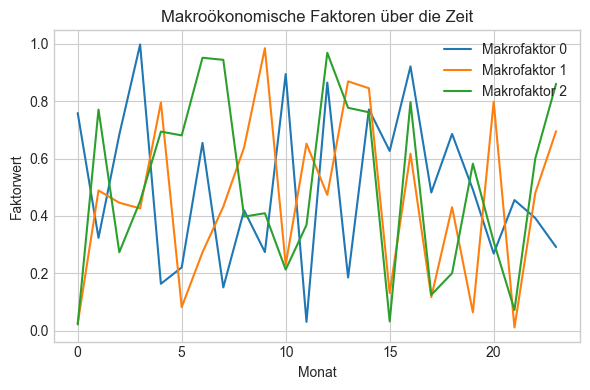

In [3]:

plt.figure(figsize=(6,4))
for stock in range(n_stocks):
    plt.plot(range(n_months), stock_characteristics[stock, :, 0], label=f'Stock {stock+1}')
plt.title('Entwicklung der Charakteristik 0 über die Zeit für alle Aktien')
plt.xlabel('Monat')
plt.ylabel('Charakteristik-Wert')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
for char in range(n_characteristics):
    plt.plot(range(n_months), stock_characteristics[0, :, char], label=f'Charakteristik {char}')
plt.title('Charakteristika einer Aktie über die Zeit (Aktie 0)')
plt.xlabel('Monat')
plt.ylabel('Charakteristik-Wert')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
for factor in range(n_macro_factors):
    plt.plot(range(n_months), macro_factors[:, factor], label=f'Makrofaktor {factor}')
plt.title('Makroökonomische Faktoren über die Zeit')
plt.xlabel('Monat')
plt.ylabel('Faktorwert')
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
X_char = stock_characteristics.transpose(1, 0, 2).reshape(n_months * n_stocks, n_characteristics)
X_macro = np.repeat(macro_factors, n_stocks, axis=0)
zi_t_flattened = np.hstack([X_char, X_macro])  # Shape: (240, 8)

true_weights = np.array([0.3] * (n_characteristics + n_macro_factors))
noise = np.random.normal(0, 0.1, size=(n_months * n_stocks))
ri_t_flattened = zi_t_flattened @ true_weights + noise  # Shape: (240,)


In [8]:
X_macro

array([[0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.7582632 , 0.02458692, 0.02212355],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.32361022, 0.48864319, 0.77040742],
       [0.68329538, 0.44590271, 0.27362667],
       [0.68329538, 0.44590271, 0.27362667],
       [0.

In [ ]:
# Erst: Training+Validation vs Test (70% / 30%)
X_temp, X_test, y_temp, y_test = train_test_split(
    zi_t_flattened, ri_t_flattened, test_size=0.3, random_state=42
)

# Jetzt: Training vs Validation (~71.43% / ~28.57% vom Rest)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2857, random_state=42
)


In [ ]:
# --- OLS Regression ---
model_ols = LinearRegression()
model_ols.fit(X_train, y_train)
y_pred_ols = model_ols.predict(X_test)
r2_ols = r2_score(y_test, y_pred_ols)
print(f"OLS R²: {r2_ols:.4f}")

In [ ]:
# --- Weighted Linear Regression (mit konstanten Gewichten als Beispiel) ---
weights = np.ones_like(y_train)  # z.B. Gleichgewichtung
model_wlr = LinearRegression()
model_wlr.fit(X_train, y_train, sample_weight=weights)
y_pred_wlr = model_wlr.predict(X_test)
r2_wlr = r2_score(y_test, y_pred_wlr)
print(f"Weighted OLS R²: {r2_wlr:.4f}")


In [ ]:
# --- Huber Regressor ---
model_huber = HuberRegressor()
model_huber.fit(X_train, y_train)
y_pred_huber = model_huber.predict(X_test)
r2_huber = r2_score(y_test, y_pred_huber)
print(f"Huber R²: {r2_huber:.4f}")


In [ ]:
# --- ElasticNet Model Tuning ---
from sklearn.linear_model import ElasticNetCV

model_enet = ElasticNetCV(cv=5)
model_enet.fit(X_train, y_train)
y_pred_enet = model_enet.predict(X_test)
r2_enet = r2_score(y_test, y_pred_enet)
print(f"ElasticNet R²: {r2_enet:.4f}")


In [ ]:
# --- Principal Component Regression (PCR) ---
from sklearn.pipeline import make_pipeline
n_components = min(X_train.shape[1], 5)

model_pcr = make_pipeline(PCA(n_components=n_components), LinearRegression())
model_pcr.fit(X_train, y_train)
y_pred_pcr = model_pcr.predict(X_test)
r2_pcr = r2_score(y_test, y_pred_pcr)
print(f"PCR R²: {r2_pcr:.4f}")


In [ ]:
# --- Partial Least Squares Regression (PLS) ---
model_pls = PLSRegression(n_components=3)
model_pls.fit(X_train, y_train)
y_pred_pls = model_pls.predict(X_test)
r2_pls = r2_score(y_test, y_pred_pls)
print(f"PLS R²: {r2_pls:.4f}")


In [ ]:
# --- Generalized Linear Model (Spline + ElasticNet) ---
from sklearn.pipeline import Pipeline

spline_transformer = SplineTransformer(n_knots=5, degree=3)
model_glm = Pipeline([
    ("spline", spline_transformer),
    ("enet", ElasticNetCV(cv=5))
])
model_glm.fit(X_train, y_train)
y_pred_glm = model_glm.predict(X_test)
r2_glm = r2_score(y_test, y_pred_glm)
print(f"GLM (Spline + ElasticNet) R²: {r2_glm:.4f}")


In [ ]:
# --- Neural Network Model ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])
model_nn.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

model_nn.fit(X_train, y_train, epochs=100, verbose=0, validation_data=(X_val, y_val))

y_pred_nn = model_nn.predict(X_test).flatten()
r2_nn = r2_score(y_test, y_pred_nn)
print(f"Neural Network R²: {r2_nn:.4f}")


In [ ]:
# --- Gradient Boosting Regressor ---
model_gb = GradientBoostingRegressor()
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting R²: {r2_gb:.4f}")


In [ ]:
# --- Random Forest Regressor ---
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest R²: {r2_rf:.4f}")


In [ ]:

model_ols = LinearRegression()
model_ols.fit(X_train, y_train)

def predict_model(model, X):
    return model.predict(X)

# Vorhersage
y_pred_ols = predict_model(model_ols, X_test)


In [ ]:
'''
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual", marker='o')
plt.plot(y_pred_ols, label="OLS Prediction", marker='x')
plt.title("OLS Regression: Predicted vs Actual Returns")
plt.xlabel("Test Sample Index")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
'''


models = {
    "OLS": y_pred_ols,
    "WLS": y_pred_wlr,
    "Huber": y_pred_huber,
    "ElasticNet": y_pred_enet,
    "PCR": y_pred_pcr,
    "PLS": y_pred_pls.ravel() if y_pred_pls.ndim > 1 else y_pred_pls,
    "GLM (Spline+EN)": y_pred_glm,
    "GradientBoosting": y_pred_gb,
    "RandomForest": y_pred_rf,
}

# Subplot conf
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()


for i, (name, y_pred) in enumerate(models.items()):
    ax = axes[i]
    ax.plot(y_test, label="Actual", marker='o')
    ax.plot(y_pred, label=f"{name} Prediction", marker='x')
    ax.set_title(name)
    ax.set_xlabel("Test Sample Index")
    ax.set_ylabel("Return")
    ax.legend()
    ax.grid(True)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [ ]:
models = {
    "OLS": y_pred_ols,
    "WLS": y_pred_wlr,
    "Huber": y_pred_huber,
    "ElasticNet": y_pred_enet,
    "PCR": y_pred_pcr,
    "PLS": y_pred_pls.ravel() if y_pred_pls.ndim > 1 else y_pred_pls,
    "GLM (Spline+EN)": y_pred_glm,
    "GradientBoosting": y_pred_gb,
    "RandomForest": y_pred_rf,
}

In [ ]:
'''
models = {
    "OLS": y_pred_ols,
    "WLS": y_pred_wlr,
    "Huber": y_pred_huber,
    "ElasticNet": y_pred_enet,
    "PCR": y_pred_pcr,
    "PLS": y_pred_pls.ravel() if y_pred_pls.ndim > 1 else y_pred_pls,
    "GLM (Spline+EN)": y_pred_glm,
    "GradientBoosting": y_pred_gb,
    "RandomForest": y_pred_rf,
}
'''

n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(models.items()):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Entferne leere Subplots

plt.tight_layout()
plt.show()


In [ ]:
'''
sse = ((y_test - y_pred_ols) ** 2).sum()
tss = ((y_test - y_test.mean()) ** 2).sum()
r2_ols_manual = 1 - (sse / tss)
print(f"Manual R² (OLS): {r2_ols_manual:.4f}")
'''
'''
models = {
    "OLS": y_pred_ols,
    "WLS": y_pred_wlr,
    "Huber": y_pred_huber,
    "ElasticNet": y_pred_enet,
    "PCR": y_pred_pcr,
    "PLS": y_pred_pls.ravel() if y_pred_pls.ndim > 1 else y_pred_pls,
    "GLM (Spline+EN)": y_pred_glm,
    "GradientBoosting": y_pred_gb,
    "RandomForest": y_pred_rf,
}
'''

# Gesamtvarianz (Total Sum of Squares)
tss = ((y_test - y_test.mean()) ** 2).sum()

# Manuelle R²-Berechnung für jedes Modell
r2_scores_manual = []
for name, y_pred in models.items():
    sse = ((y_test - y_pred) ** 2).sum()  # Residuenquadratsumme
    r2_manual = 1 - (sse / tss)
    r2_scores_manual.append((name, r2_manual))

# In DataFrame speichern
r2_df = pd.DataFrame(r2_scores_manual, columns=["Model", "Manual_R2"])
r2_df.sort_values(by="Manual_R2", ascending=False, inplace=True)

print(r2_df)



In [ ]:
from scipy.stats import ttest_rel

# Referenzmodell (z. B. RandomForest)
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

# Quadratische Fehler vergleichen
errors_ols = y_test - y_pred_ols
errors_rf = y_test - y_pred_rf

dm_stat, p_value = ttest_rel(errors_ols**2, errors_rf**2)
print(f"Diebold-Mariano-like Test: t = {dm_stat:.4f}, p = {p_value:.4f}")


In [ ]:
'''
def compute_ols_variable_importance(X_train, y_train, X_test, y_test):
    base_model = LinearRegression()
    base_model.fit(X_train, y_train)
    base_r2 = r2_score(y_test, base_model.predict(X_test))

    importances = []
    for i in range(X_train.shape[1]):
        X_train_drop = np.delete(X_train, i, axis=1)
        X_test_drop = np.delete(X_test, i, axis=1)

        model = LinearRegression()
        model.fit(X_train_drop, y_train)
        r2_drop = r2_score(y_test, model.predict(X_test_drop))
        importances.append(base_r2 - r2_drop)
    
    return np.array(importances)

# Wichtigkeiten berechnen
importance_ols = compute_ols_variable_importance(X_train, y_train, X_test, y_test)
'''
# Funktion zur Berechnung der R²-Drop-Importance
def compute_variable_importance(model_class, X_train, y_train, X_test, y_test, **model_kwargs):
    base_model = model_class(**model_kwargs)
    base_model.fit(X_train, y_train)
    base_r2 = r2_score(y_test, base_model.predict(X_test))

    importances = []
    for i in range(X_train.shape[1]):
        X_train_drop = np.delete(X_train, i, axis=1)
        X_test_drop = np.delete(X_test, i, axis=1)
        model = model_class(**model_kwargs)
        model.fit(X_train_drop, y_train)
        r2_drop = r2_score(y_test, model.predict(X_test_drop))
        importances.append(base_r2 - r2_drop)
    return importances


models_info = {
    "OLS": (LinearRegression, {}),
    "WLS": (LinearRegression, {"sample_weight": np.ones_like(y_train)}),  # wird separat behandelt
    "Huber": (HuberRegressor, {}),
    "ElasticNet": (ElasticNetCV, {"cv": 5}),
    "PCR": (lambda: make_pipeline(PCA(n_components=min(X_train.shape[1], 5)), LinearRegression()), {}),
    "PLS": (PLSRegression, {"n_components": 3}),
    "GLM (Spline+EN)": (lambda: Pipeline([
        ("spline", SplineTransformer(n_knots=5, degree=3)),
        ("enet", ElasticNetCV(cv=5))
    ]), {}),
    "GradientBoosting": (GradientBoostingRegressor, {}),
    "RandomForest": (RandomForestRegressor, {}),
}

# Variable Importance für alle Modelle sammeln
importance_matrix = []
model_names = []
for name, (model_class, kwargs) in models_info.items():
    try:
        if name == "WLS":
            # Spezialfall: sample_weight beim Fit übergeben
            model = LinearRegression()
            model.fit(X_train, y_train, sample_weight=kwargs["sample_weight"])
            base_r2 = r2_score(y_test, model.predict(X_test))
            importances = []
            for i in range(X_train.shape[1]):
                X_train_drop = np.delete(X_train, i, axis=1)
                X_test_drop = np.delete(X_test, i, axis=1)
                m = LinearRegression()
                m.fit(X_train_drop, y_train, sample_weight=kwargs["sample_weight"])
                r2_drop = r2_score(y_test, m.predict(X_test_drop))
                importances.append(base_r2 - r2_drop)
        else:
            # Für normale Modelle
            if callable(model_class):
                model_class_instance = model_class  # z.B. lambda-Funktionen für Pipelines
            else:
                model_class_instance = lambda **kw: model_class(**kw)
            importances = compute_variable_importance(model_class_instance, X_train, y_train, X_test, y_test, **kwargs)
        importance_matrix.append(importances)
        model_names.append(name)
    except Exception as e:
        print(f"Skipping {name} due to error: {e}")



In [ ]:
import seaborn as sns

# Heatmap erstellen
importance_df = pd.DataFrame(importance_matrix, index=model_names, columns=[f"X{i}" for i in range(X_train.shape[1])])

plt.figure(figsize=(12, 6))
sns.heatmap(importance_df, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Variable Importance via R²-Drop (Feature Removal)")
plt.xlabel("Feature")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


In [ ]:

def decile_portfolio_analysis(y_true, y_pred):
    df = pd.DataFrame({'actual': y_true, 'pred': y_pred})
    df['decile'] = pd.qcut(df['pred'], 10, labels=False)

    summary = df.groupby('decile').agg(
        avg_return=('actual', 'mean'),
        std_return=('actual', 'std')
    )
    summary['sharpe'] = summary['avg_return'] / summary['std_return']
    return summary

# Analyse
decile_summary_ols = decile_portfolio_analysis(y_test, y_pred_ols)
print(decile_summary_ols)


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

decile_summary_ols['avg_return'].plot(kind='bar', ax=ax[0], title='Average Return by Decile (OLS)')
decile_summary_ols['sharpe'].plot(kind='bar', ax=ax[1], title='Sharpe Ratio by Decile (OLS)')

ax[0].set_xlabel("Predicted Return Decile")
ax[1].set_xlabel("Predicted Return Decile")
ax[0].set_ylabel("Average Return")
ax[1].set_ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import ttest_rel
import pandas as pd
import numpy as np

'''
models = {
    "OLS": y_pred_ols,
    "WLS": y_pred_wlr,
    "Huber": y_pred_huber,
    "ElasticNet": y_pred_enet,
    "PCR": y_pred_pcr,
    "PLS": y_pred_pls.ravel() if y_pred_pls.ndim > 1 else y_pred_pls,
    "GLM (Spline+EN)": y_pred_glm,
    "GradientBoosting": y_pred_gb,
    "RandomForest": y_pred_rf,
}
'''

errors_squared = {name: (y_test - y_pred) ** 2 for name, y_pred in models.items()}

# Paarweise jeder mit jedme
results = []
model_names = list(models.keys())

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        err1, err2 = errors_squared[m1], errors_squared[m2]
        stat, pval = ttest_rel(err1, err2)
        winner = m1 if err1.mean() < err2.mean() else m2

        results.append({
            "Model 1": m1,
            "Model 2": m2,
            "MSE 1": err1.mean(),
            "MSE 2": err2.mean(),
            "DM t-stat": stat,
            "p-value": pval,
            "Winner": winner
        })

df_compare = pd.DataFrame(results)

# Ausgabe anzeigen
print(df_compare.sort_values(by="p-value"))


In [ ]:
df_compare.head(44)

In [ ]:

def decile_portfolio_analysis(y_true, y_pred):
    df = pd.DataFrame({'actual': y_true, 'pred': y_pred})
    df['decile'] = pd.qcut(df['pred'], 10, labels=False)
    summary = df.groupby('decile').agg(
        avg_return=('actual', 'mean'),
        std_return=('actual', 'std')
    )
    summary['sharpe'] = summary['avg_return'] / summary['std_return']
    return summary

models = {
    "OLS": y_pred_ols,
    "WLS": y_pred_wlr,
    "Huber": y_pred_huber,
    "ElasticNet": y_pred_enet,
    "PCR": y_pred_pcr,
    "PLS": y_pred_pls.ravel() if y_pred_pls.ndim > 1 else y_pred_pls,
    "GLM (Spline+EN)": y_pred_glm,
    "GradientBoosting": y_pred_gb,
    "RandomForest": y_pred_rf,
}

colors = sns.color_palette("tab10", n_colors=len(models))
model_colors = {model: color for model, color in zip(models.keys(), colors)}

fig, axes = plt.subplots(len(models), 2, figsize=(14, 3 * len(models)))
if len(models) == 1:
    axes = axes.reshape(1, 2)

top_decile_stats = []

for idx, (model_name, y_pred) in enumerate(models.items()):
    summary = decile_portfolio_analysis(y_test, y_pred)
    top_decile_stats.append({
        "Model": model_name,
        "Top Decile Avg Return": summary['avg_return'].iloc[-1],
        "Top Decile Sharpe": summary['sharpe'].iloc[-1]
    })

    # Plot avg return
    summary['avg_return'].plot(kind='bar', ax=axes[idx, 0], color=model_colors[model_name])
    axes[idx, 0].set_title(f"{model_name} - Avg Return by Decile")
    axes[idx, 0].set_ylabel("Avg Return")
    axes[idx, 0].set_xlabel("Predicted Return Decile")

    # Plot Sharpe Ratio
    summary['sharpe'].plot(kind='bar', ax=axes[idx, 1], color=model_colors[model_name])
    axes[idx, 1].set_title(f"{model_name} - Sharpe Ratio by Decile")
    axes[idx, 1].set_ylabel("Sharpe Ratio")
    axes[idx, 1].set_xlabel("Predicted Return Decile")

plt.tight_layout()
plt.show()

ranking_df = pd.DataFrame(top_decile_stats)
ranking_df = ranking_df.sort_values(by="Top Decile Avg Return", ascending=False)
print(ranking_df)
